## Helper functions

In [1]:
import pandas as pd
from pathlib import Path
file_name = 'Front_EE-1_1_3000x_rings_coords.csv'
path_to_main_folder = Path('/Users/rishabhkumar/spiral-chirals')
# csv_file = Path('/Users/rishabhkumar/spiral-chirals/vf_exports/Front_EE-1_1_3000x_rings_coords.csv')
csv_file = path_to_main_folder / 'vf_exports' / file_name
with open(csv_file, 'r') as f:
    df = pd.read_csv(f)

print(df.head())
# remove the last row 
df = df.iloc[:-1]


  Ring     Coordinate  Angle (α′)        Pattern
0    1   (7.00, 0.00)      -26.09      Clockwise
1    1  (0.00, -7.00)       58.86  Anticlockwise
2    1  (-7.00, 0.00)      -31.99      Clockwise
3    1   (0.00, 7.00)       73.30  Anticlockwise
4    2  (43.00, 0.00)      -11.86      Clockwise


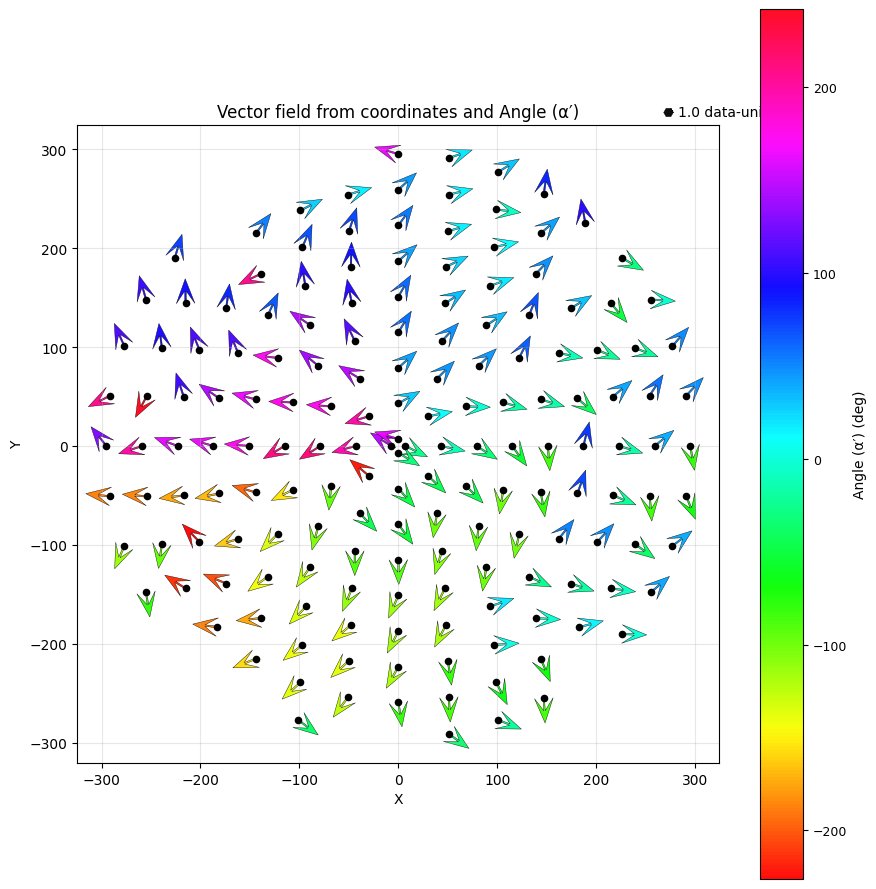

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# helper functions 
import ast

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)          # handles "(7.00, 0.00)" or "[7.00, 0.00]"
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]
# Extract angles and filter valid data
angles_deg = df['Angle (α′)'].values 

# df['Coordinate'] = df['Coordinate'].apply(lambda x: np.array(x))    
coordinates = df['Coordinate'].apply(parse_coord).tolist()
# Find global theta from the coordinates 

# For these angles and coordinates, plot a vector field
X = [coord[0] for coord in coordinates]
Y = [coord[1] for coord in coordinates]
r = np.sqrt(np.array(X)**2 + np.array(Y)**2)
theta = np.arctan2(
    np.array(Y),
    np.array(X)
)
phi = angles_deg + np.degrees(theta)
phi_rad = np.deg2rad(phi)
U_plot = np.cos(phi_rad)
V_plot = np.sin(phi_rad)
# Compute a reasonable scale factor for the quiver key
scale_factor = np.round(np.percentile(np.sqrt(U_plot**2 + V_plot**2), 75), 1)
if scale_factor == 0:
    scale_factor = 1.0
# Create the plot
plt.figure(figsize=(9, 9))
magnitude_scale = 25.0
U_plot_scaled = magnitude_scale * U_plot
V_plot_scaled = magnitude_scale * V_plot
q = plt.quiver(
    X, Y, U_plot_scaled, V_plot_scaled, phi,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Vector field from coordinates and Angle (α′)')
cbar = plt.colorbar(q, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('vector_field_plot.svg', dpi=300)
plt.show()

In [ ]:
## Likelihood calculation using line field approach
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def line_field_pdf(psi, phi_0, m, sigma):
    """
    Calculates the probability density for the line field model.
    
    Args:
        psi (float or np.array): The data points (angles in radians).
        phi_0 (float): The orientation parameter to estimate.
        m (float): Magnitude/strength parameter.
        sigma (float): Standard deviation parameter.
        
    Returns:
        np.array: The probability density values.
    """
    # Calculate the angular difference
    delta = psi - phi_0
    
    # Pre-calculate common terms for efficiency
    cos_d = np.cos(delta)
    sin_d = np.sin(delta)
    m_sigma_ratio = m / sigma
    
    # Term 1: The isotropic baseline
    # Note: Using 1/pi as per your handwritten note
    term1 = (1.0 / np.pi) * np.exp(-0.5 * (m_sigma_ratio**2))
    
    # Term 2: The directional component
    # The exponential part: exp(-m^2 * sin^2 / 2sigma^2)
    exp_part = np.exp(-0.5 * (m_sigma_ratio * sin_d)**2)
    
    # The Phi part: 2 * Phi(...) - 1
    # Note: norm.cdf is the standard normal CDF (Phi)
    phi_arg = m_sigma_ratio * cos_d
    bracket_term = 2 * norm.cdf(phi_arg) - 1
    
    # Combine Term 2
    # coefficient: m * cos(delta) * (1 / (sqrt(2pi) * sigma))
    coeff = m * cos_d * (1.0 / (np.sqrt(2 * np.pi) * sigma))
    term2 = coeff * exp_part * bracket_term
    
    return term1 + term2

def neg_log_likelihood(params, psi_data, m, sigma):
    """
    The objective function to minimize.
    """
    phi_0 = params[0]
    
    # Calculate PDF values
    pdf_vals = line_field_pdf(psi_data, phi_0, m, sigma)
    
    # Safety check: Prevent log(0) or negative values due to float precision
    epsilon = 1e-15
    pdf_vals = np.maximum(pdf_vals, epsilon)
    
    # Return negative sum of logs
    return -np.sum(np.log(pdf_vals))

# --- Example Usage ---

# 1. Generate Dummy Data (Ground Truth: phi_0 = 1.0 radian)

# 3. Output Results
if result.success:
    estimated_phi = result.x[0]
    print(f"Optimization Successful!")
    print(f"True Phi_0 (approx): {true_phi}")
    print(f"Estimated Phi_0:     {estimated_phi:.4f}")
    print(f"Negative Log Likelihood: {result.fun:.4f}")
else:
    print("Optimization failed:", result.message)

Optimization Successful!
True Phi_0 (approx): 1.0
Estimated Phi_0:     0.9836
Negative Log Likelihood: 90.5293
